In [19]:
# ================================================================
# Preprocessing et Modélisation - Prédiction des Prix des Maisons
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [20]:
# Configuration des graphiques
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")
sns.set_palette("husl")


In [21]:
# ================================================================
# I. PREPROCESSING
# ================================================================

print("="*70)
print("PARTIE I: PREPROCESSING")
print("="*70)


PARTIE I: PREPROCESSING


In [22]:
# ----------------------------------------------------------------
# 1. CHARGEMENT ET STATISTIQUES DESCRIPTIVES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("1. CHARGEMENT DES DONNÉES ET STATISTIQUES DESCRIPTIVES")
print("-"*70)

# Chargement des données
df = pd.read_csv('train.csv')
print(f'Dimension de dataset {df.shape}')
print(f"Nombre total d'observations {df.shape[0]}")
print(f"Nombre total de variables {df.shape[1]}")
print(f"Nombre total de cellules {df.shape[1]*df.shape[0]}")


----------------------------------------------------------------------
1. CHARGEMENT DES DONNÉES ET STATISTIQUES DESCRIPTIVES
----------------------------------------------------------------------
Dimension de dataset (1460, 81)
Nombre total d'observations 1460
Nombre total de variables 81
Nombre total de cellules 118260


* NaN : valeur manquante
* None : indique absence d'un feature

In [23]:
# Statistiques descriptives générales
print("\nSTATISTIQUES DESCRIPTIVES - Variables Numériques:")
print(df.describe().T)

print("\nSTATISTIQUES DE LA VARIABLE CIBLE (SalePrice):")
print(f"  Moyenne: ${df['SalePrice'].mean():,.2f}")
print(f"  Médiane: ${df['SalePrice'].median():,.2f}")
print(f"  Écart-type: ${df['SalePrice'].std():,.2f}")
print(f"  Min: ${df['SalePrice'].min():,.2f}")
print(f"  Max: ${df['SalePrice'].max():,.2f}")


STATISTIQUES DESCRIPTIVES - Variables Numériques:
                count           mean           std      min        25%  \
Id             1460.0     730.500000    421.610009      1.0     365.75   
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00   
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00   
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50   
OverallQual    1460.0       6.099315      1.382997      1.0       5.00   
OverallCond    1460.0       5.575342      1.112799      1.0       5.00   
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00   
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0    1967.00   
MasVnrArea     1452.0     103.685262    181.066207      0.0       0.00   
BsmtFinSF1     1460.0     443.639726    456.098091      0.0       0.00   
BsmtFinSF2     1460.0      46.549315    161.319273      0.0       0.00   
BsmtUnfSF      1460.0     567.240411    441.866955      0.0  

In [24]:
# ----------------------------------------------------------------
# 2. ANALYSE DES VALEURS MANQUANTES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("2. ANALYSE ET TRAITEMENT DES VALEURS MANQUANTES")
print("-"*70)

# Calcul des valeurs manquantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Nb_Manquant': missing_data.values,
    'Pourcentage': missing_percent.values
}).sort_values('Pourcentage', ascending=False)

missing_cols = missing_df[missing_df['Nb_Manquant'] > 0]
print(f"\nNombre de colonnes avec valeurs manquantes: {len(missing_cols)}")
print("\nTop 10 des colonnes avec le plus de valeurs manquantes:")
print(missing_cols.head(10))

# Stratégie de traitement des valeurs manquantes
print("\nSTRATÉGIE DE TRAITEMENT:")

# Variables où NA signifie "None" ou "No feature"
na_means_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']

# Remplir avec "None" pour les variables catégoriques
for col in na_means_none:
    if col in df.columns:
        df[col] = df[col].fillna('None')
        print(f"  • {col}: rempli avec 'None'")

# Remplir avec 0 pour les variables numériques liées
numeric_na_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                   'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
                   'BsmtHalfBath', 'MasVnrArea']

for col in numeric_na_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"  • {col}: rempli avec 0")

# LotFrontage: remplir avec la médiane du quartier
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"  • LotFrontage: rempli avec médiane par quartier")

# Electrical: remplir avec le mode
if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    print(f"  • Electrical: rempli avec le mode")

# Vérification finale
remaining_missing = df.isnull().sum().sum()
print(f"\nValeurs manquantes restantes: {remaining_missing}")



----------------------------------------------------------------------
2. ANALYSE ET TRAITEMENT DES VALEURS MANQUANTES
----------------------------------------------------------------------

Nombre de colonnes avec valeurs manquantes: 19

Top 10 des colonnes avec le plus de valeurs manquantes:
        Variable  Nb_Manquant  Pourcentage
72        PoolQC         1453    99.520548
74   MiscFeature         1406    96.301370
6          Alley         1369    93.767123
73         Fence         1179    80.753425
25    MasVnrType          872    59.726027
57   FireplaceQu          690    47.260274
3    LotFrontage          259    17.739726
63    GarageQual           81     5.547945
60  GarageFinish           81     5.547945
58    GarageType           81     5.547945

STRATÉGIE DE TRAITEMENT:
  • PoolQC: rempli avec 'None'
  • MiscFeature: rempli avec 'None'
  • Alley: rempli avec 'None'
  • Fence: rempli avec 'None'
  • FireplaceQu: rempli avec 'None'
  • GarageType: rempli avec 'None'
  • Gar

In [25]:
# ----------------------------------------------------------------
# 3. DISTINCTION VARIABLES NUMÉRIQUES ET CATÉGORIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("3. DISTINCTION VARIABLES NUMÉRIQUES ET CATÉGORIQUES")
print("-"*70)

# Identification des types de variables
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Retirer Id et SalePrice des features
if 'Id' in numeric_features:
    numeric_features.remove('Id')
if 'SalePrice' in numeric_features:
    target = 'SalePrice'
    numeric_features.remove('SalePrice')

print(f"Variables numériques: {len(numeric_features)}")
print(f"  Exemples: {numeric_features[:10]}")
print(f"\nVariables catégoriques: {len(categorical_features)}")
print(f"  Exemples: {categorical_features[:10]}")



----------------------------------------------------------------------
3. DISTINCTION VARIABLES NUMÉRIQUES ET CATÉGORIQUES
----------------------------------------------------------------------
Variables numériques: 36
  Exemples: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

Variables catégoriques: 43
  Exemples: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']



----------------------------------------------------------------------
4. DISTRIBUTION DES VARIABLES NUMÉRIQUES
----------------------------------------------------------------------

DISTRIBUTION DE LA VARIABLE CIBLE (SalePrice):
  Skewness: 1.8809
  Kurtosis: 6.5098


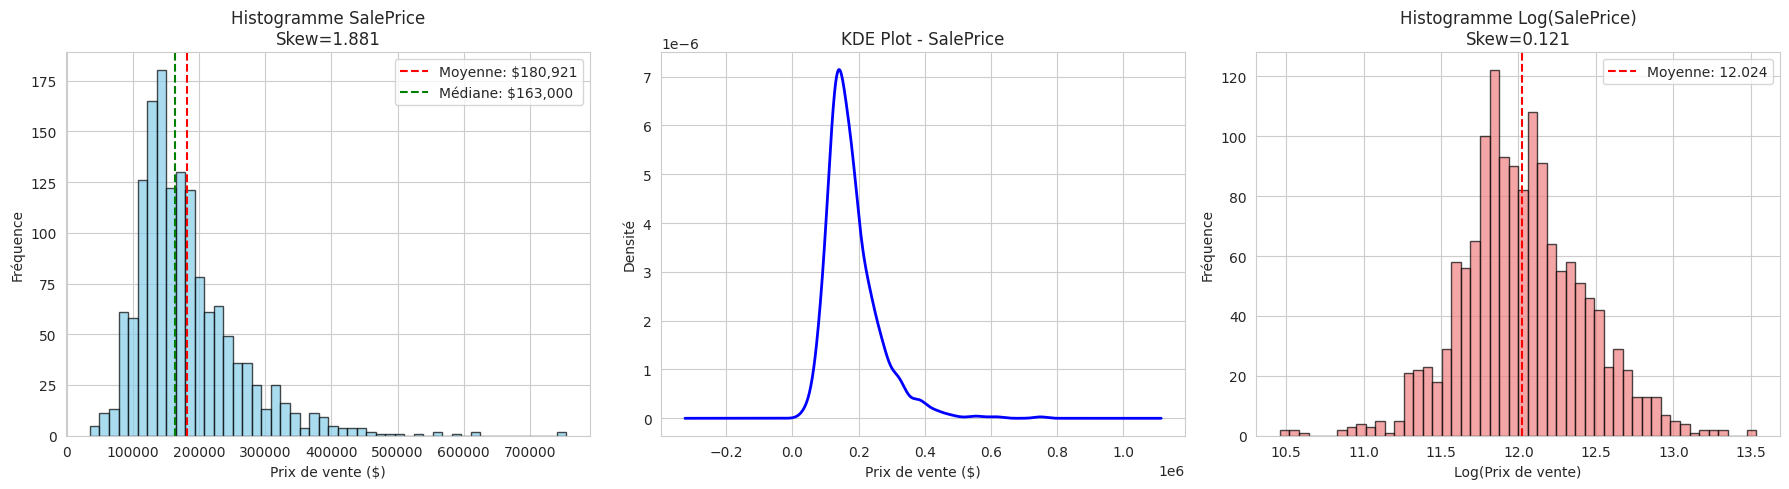


ANALYSE DES PRINCIPALES VARIABLES NUMÉRIQUES:
--------------------------------------------------
      Variable   Skewness    Kurtosis Interprétation_Skew
0      LotArea  12.195142  202.543793  Asymétrique droite
1  OverallQual   0.216721    0.091857  Presque symétrique
2  OverallCond   0.692355    1.098521  Presque symétrique
3    YearBuilt  -0.612831   -0.442155  Presque symétrique
4  TotalBsmtSF   1.522688   13.201042  Asymétrique droite
5    GrLivArea   1.365156    4.874266  Asymétrique droite
6     FullBath   0.036524   -0.858217  Presque symétrique
7   GarageCars  -0.342197    0.216135  Presque symétrique


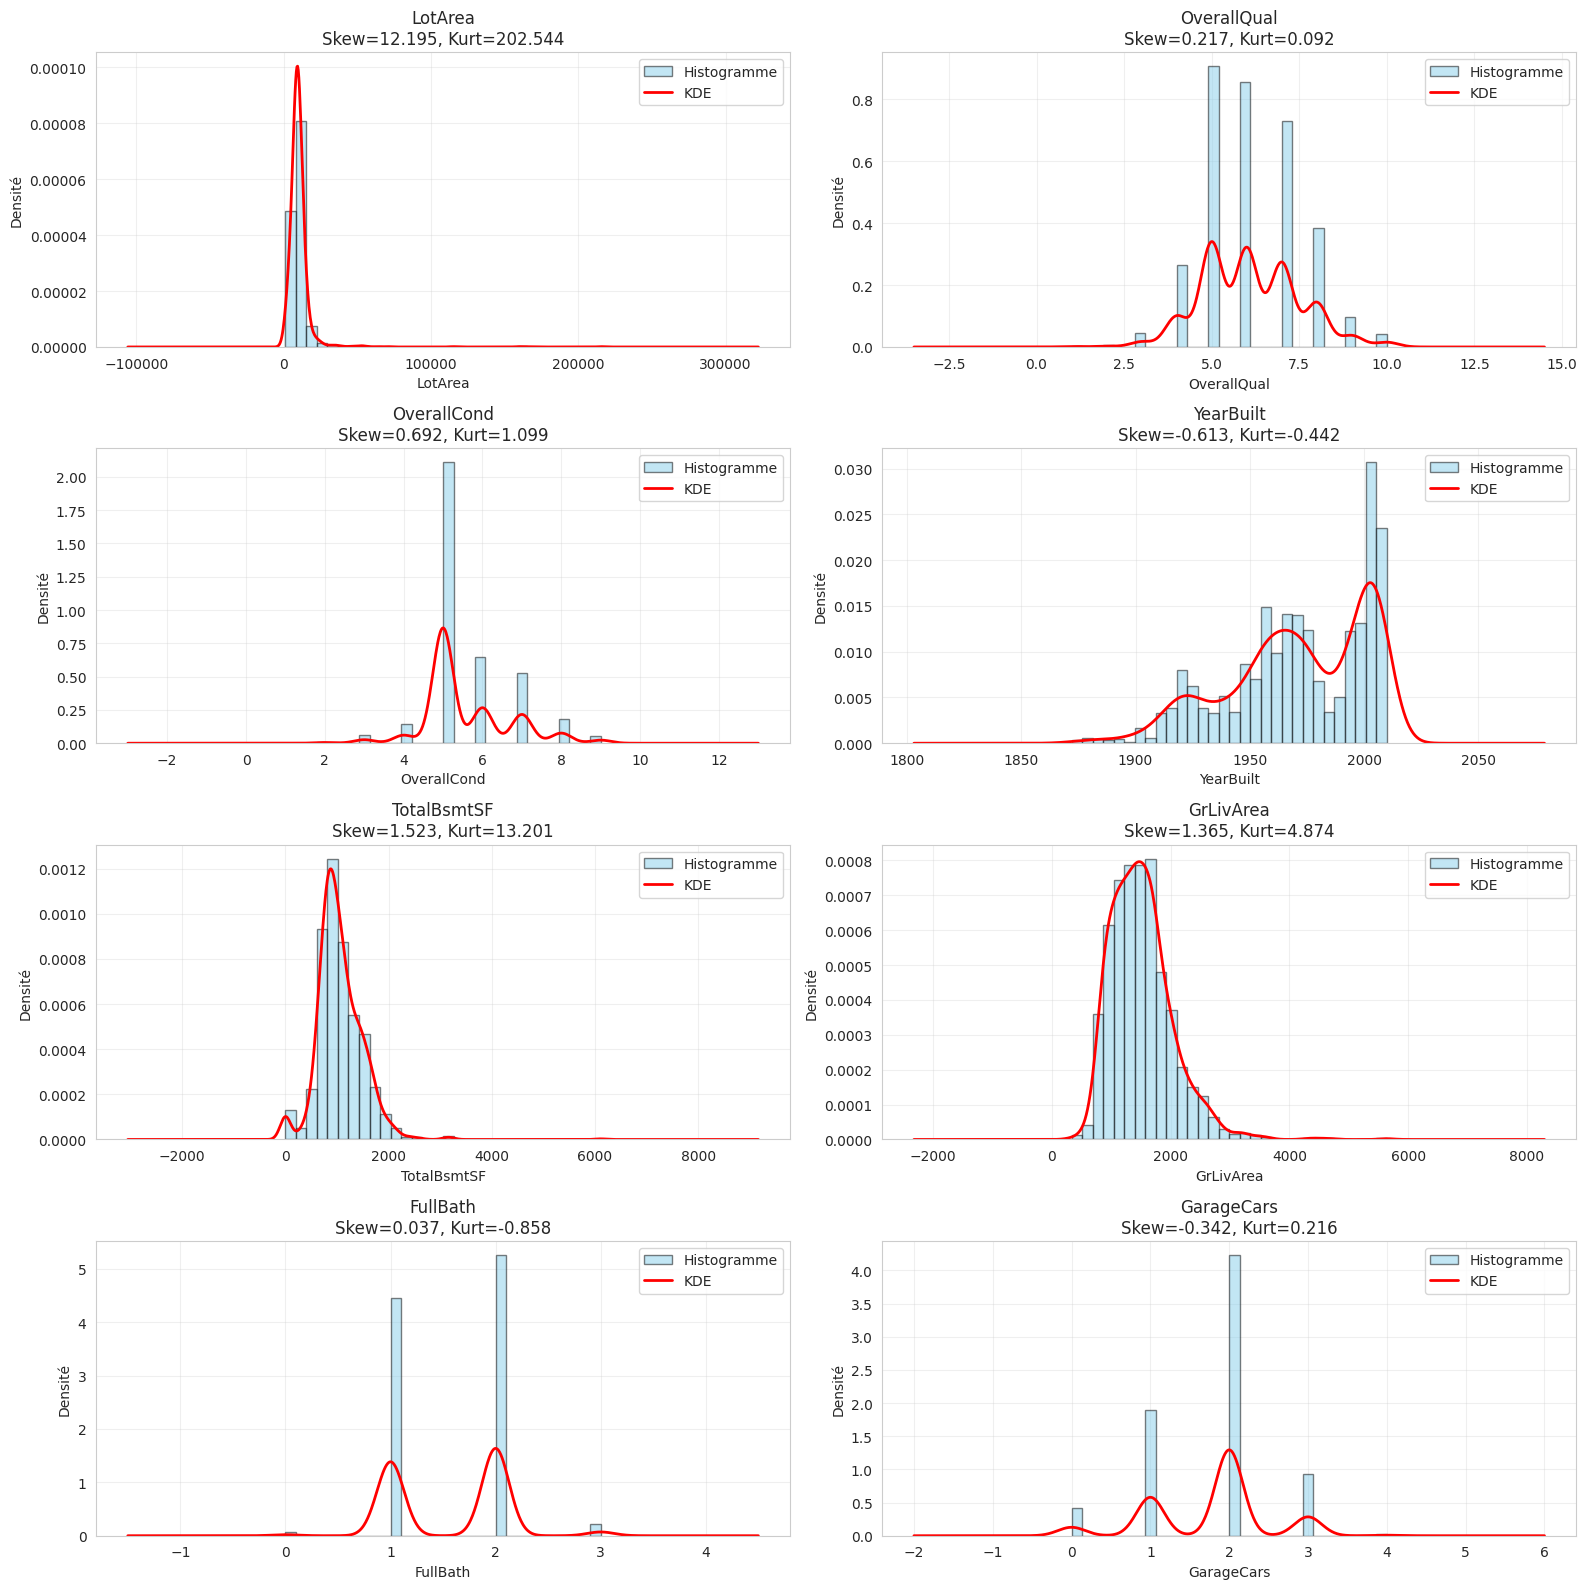


SKEWNESS ET KURTOSIS - TOUTES LES VARIABLES NUMÉRIQUES:
----------------------------------------------------------
         Variable   Skewness    Kurtosis
33        MiscVal  24.451640  698.600840
32       PoolArea  14.813135  222.500507
2         LotArea  12.195142  202.543793
30      3SsnPorch  10.293752  123.235177
14   LowQualFinSF   9.002080   82.945932
21   KitchenAbvGr   4.483784   21.454627
9      BsmtFinSF2   4.250888   20.040415
31    ScreenPorch   4.117977   18.371874
17   BsmtHalfBath   4.099186   16.336436
24    GarageYrBlt  -3.865524   12.994493
29  EnclosedPorch   3.086696   10.390972
7      MasVnrArea   2.674865   10.102612
28    OpenPorchSF   2.361912    8.457180
1     LotFrontage   2.210685   20.026234
8      BsmtFinSF1   1.683771   11.076090

Nombre de variables fortement asymétriques (|skew| > 1): 20


In [26]:
# ----------------------------------------------------------------
# 4. DISTRIBUTION DES VARIABLES NUMÉRIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("4. DISTRIBUTION DES VARIABLES NUMÉRIQUES")
print("-"*70)

# Analyse de la variable cible
print("\nDISTRIBUTION DE LA VARIABLE CIBLE (SalePrice):")
print(f"  Skewness: {skew(df['SalePrice']):.4f}")
print(f"  Kurtosis: {kurtosis(df['SalePrice']):.4f}")

# Visualisation de SalePrice
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme
axes[0].hist(df['SalePrice'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--',
                label=f'Moyenne: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--',
                label=f'Médiane: ${df["SalePrice"].median():,.0f}')
axes[0].set_xlabel('Prix de vente ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Histogramme SalePrice\nSkew={skew(df["SalePrice"]):.3f}')
axes[0].legend()

# KDE Plot
df['SalePrice'].plot(kind='density', ax=axes[1], color='blue', linewidth=2)
axes[1].set_xlabel('Prix de vente ($)')
axes[1].set_ylabel('Densité')
axes[1].set_title('KDE Plot - SalePrice')
axes[1].grid(True)

# Distribution log-normale
log_price = np.log(df['SalePrice'])
axes[2].hist(log_price, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[2].axvline(log_price.mean(), color='red', linestyle='--',
                label=f'Moyenne: {log_price.mean():.3f}')
axes[2].set_xlabel('Log(Prix de vente)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title(f'Histogramme Log(SalePrice)\nSkew={skew(log_price):.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Analyse des principales variables numériques
print("\nANALYSE DES PRINCIPALES VARIABLES NUMÉRIQUES:")
print("-" * 50)

# Sélection des variables numériques importantes
important_numeric = ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
                     'TotalBsmtSF', 'GrLivArea', 'FullBath', 'GarageCars']

skewness_data = []
for col in important_numeric:
    if col in df.columns:
        skew_val = skew(df[col])
        kurt_val = kurtosis(df[col])
        skewness_data.append({
            'Variable': col,
            'Skewness': skew_val,
            'Kurtosis': kurt_val,
            'Interprétation_Skew': 'Asymétrique droite' if skew_val > 1
                                   else 'Asymétrique gauche' if skew_val < -1
                                   else 'Presque symétrique'
        })

skewness_df = pd.DataFrame(skewness_data)
print(skewness_df)

# Visualisation des distributions
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for i, col in enumerate(important_numeric):
    if col in df.columns and i < len(axes):
        # Histogramme + KDE
        axes[i].hist(df[col], bins=30, alpha=0.5, color='skyblue',
                    edgecolor='black', density=True, label='Histogramme')
        df[col].plot(kind='density', ax=axes[i], color='red',
                    linewidth=2, label='KDE')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densité')
        axes[i].set_title(f'{col}\nSkew={skew(df[col]):.3f}, Kurt={kurtosis(df[col]):.3f}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcul du skewness et kurtosis pour toutes les variables numériques
print("\nSKEWNESS ET KURTOSIS - TOUTES LES VARIABLES NUMÉRIQUES:")
print("-" * 58)

all_skewness = []
for col in numeric_features:
    if col in df.columns:
        skew_val = skew(df[col])
        kurt_val = kurtosis(df[col])
        all_skewness.append({
            'Variable': col,
            'Skewness': skew_val,
            'Kurtosis': kurt_val
        })

all_skewness_df = pd.DataFrame(all_skewness).sort_values('Skewness',
                                                          ascending=False,
                                                          key=abs)
print(all_skewness_df.head(15))

# Variables fortement asymétriques (|skew| > 1)
highly_skewed = all_skewness_df[abs(all_skewness_df['Skewness']) > 1]
print(f"\nNombre de variables fortement asymétriques (|skew| > 1): {len(highly_skewed)}")



----------------------------------------------------------------------
5. DISTRIBUTION DES VARIABLES CATÉGORIQUES
----------------------------------------------------------------------

DISTRIBUTION DES PRINCIPALES VARIABLES CATÉGORIQUES:


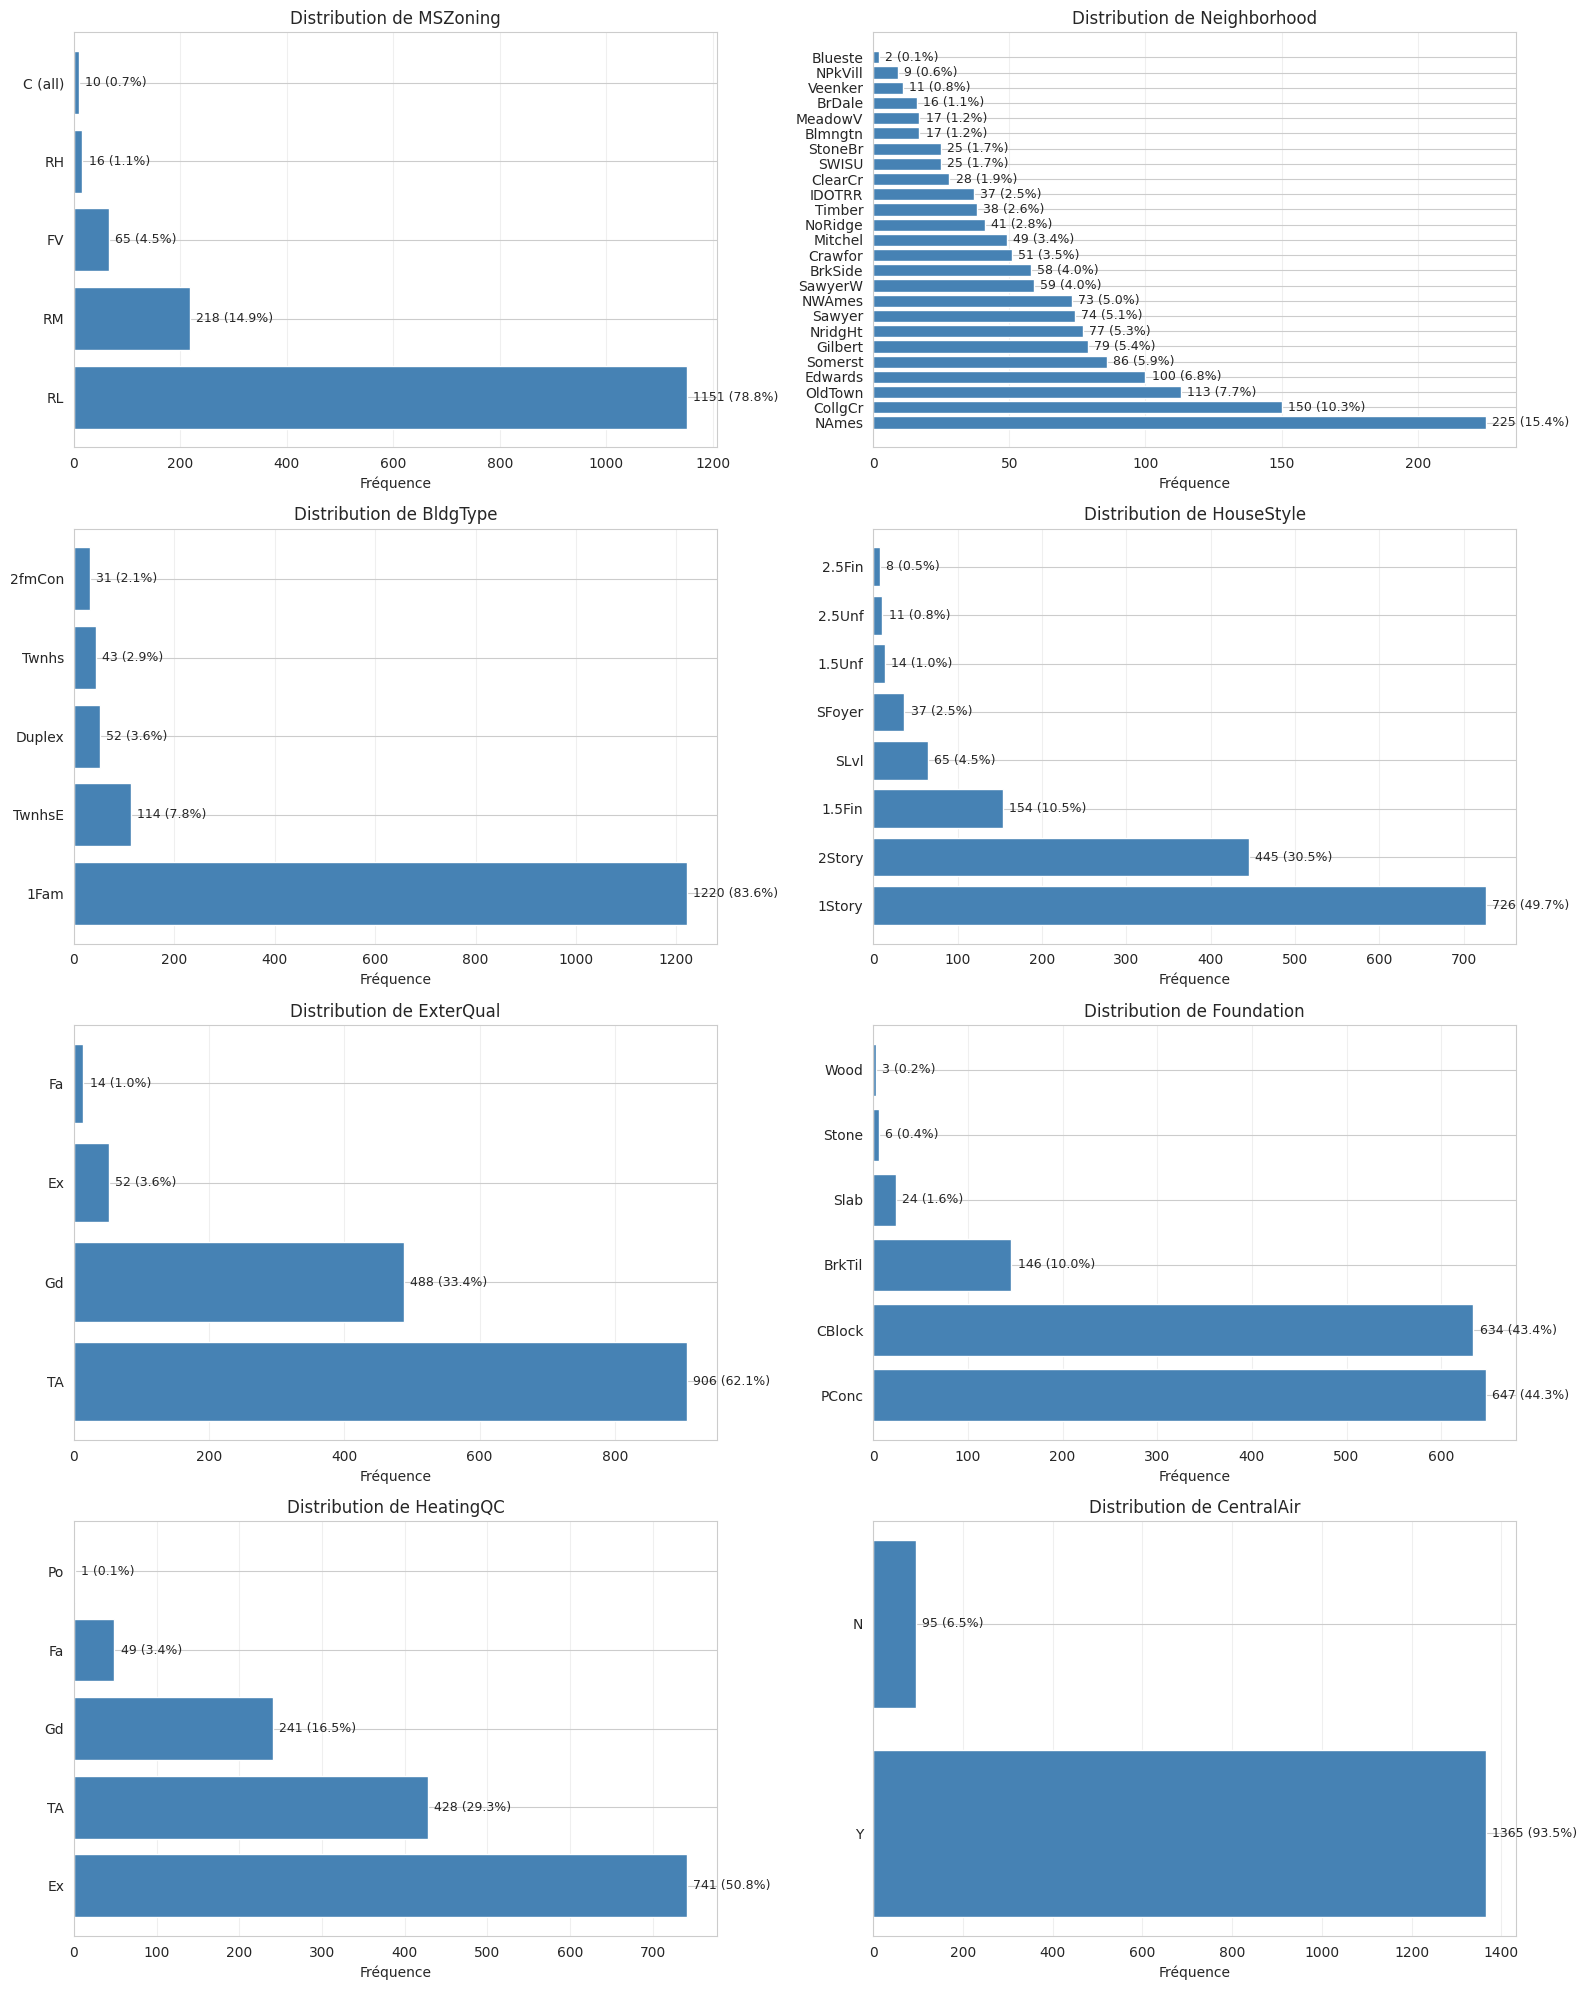


STATISTIQUES DES VARIABLES CATÉGORIQUES:
------------------------------------------
        Variable  Nb_Catégories Catégorie_Dominante  Fréq_Dominante  \
8   Neighborhood             25               NAmes             225   
16   Exterior2nd             16             VinylSd             504   
15   Exterior1st             15             VinylSd             515   
9     Condition1              9                Norm            1260   
41      SaleType              9                  WD            1267   
12    HouseStyle              8              1Story             726   
14      RoofMatl              8             CompShg            1434   
10    Condition2              8                Norm            1445   
25  BsmtFinType2              7                 Unf            1256   
24  BsmtFinType1              7                 Unf             430   

   Pct_Dominante  
8          15.4%  
16         34.5%  
15         35.3%  
9          86.3%  
41         86.8%  
12         49.7%  


In [27]:
# ----------------------------------------------------------------
# 5. DISTRIBUTION DES VARIABLES CATÉGORIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("5. DISTRIBUTION DES VARIABLES CATÉGORIQUES")
print("-"*70)

# Analyse des variables catégoriques principales
important_categorical = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle',
                         'ExterQual', 'Foundation', 'HeatingQC', 'CentralAir']

print("\nDISTRIBUTION DES PRINCIPALES VARIABLES CATÉGORIQUES:")

# Barres horizontales pour les variables catégoriques
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for i, col in enumerate(important_categorical):
    if col in df.columns and i < len(axes):
        value_counts = df[col].value_counts()
        axes[i].barh(range(len(value_counts)), value_counts.values, color='steelblue')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Fréquence')
        axes[i].set_title(f'Distribution de {col}')
        axes[i].grid(axis='x', alpha=0.3)

        # Ajouter les valeurs
        for j, v in enumerate(value_counts.values):
            axes[i].text(v + max(value_counts.values)*0.01, j,
                        f'{v} ({v/len(df)*100:.1f}%)',
                        va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Statistiques des variables catégoriques
print("\nSTATISTIQUES DES VARIABLES CATÉGORIQUES:")
print("-" * 42)
cat_stats = []
for col in categorical_features:
    if col in df.columns:
        cat_stats.append({
            'Variable': col,
            'Nb_Catégories': df[col].nunique(),
            'Catégorie_Dominante': df[col].mode()[0],
            'Fréq_Dominante': df[col].value_counts().iloc[0],
            'Pct_Dominante': f"{(df[col].value_counts().iloc[0]/len(df)*100):.1f}%"
        })

cat_stats_df = pd.DataFrame(cat_stats).sort_values('Nb_Catégories', ascending=False)
print(cat_stats_df.head(10))




----------------------------------------------------------------------
6. BOXPLOTS POUR DÉTECTER LES OUTLIERS
----------------------------------------------------------------------


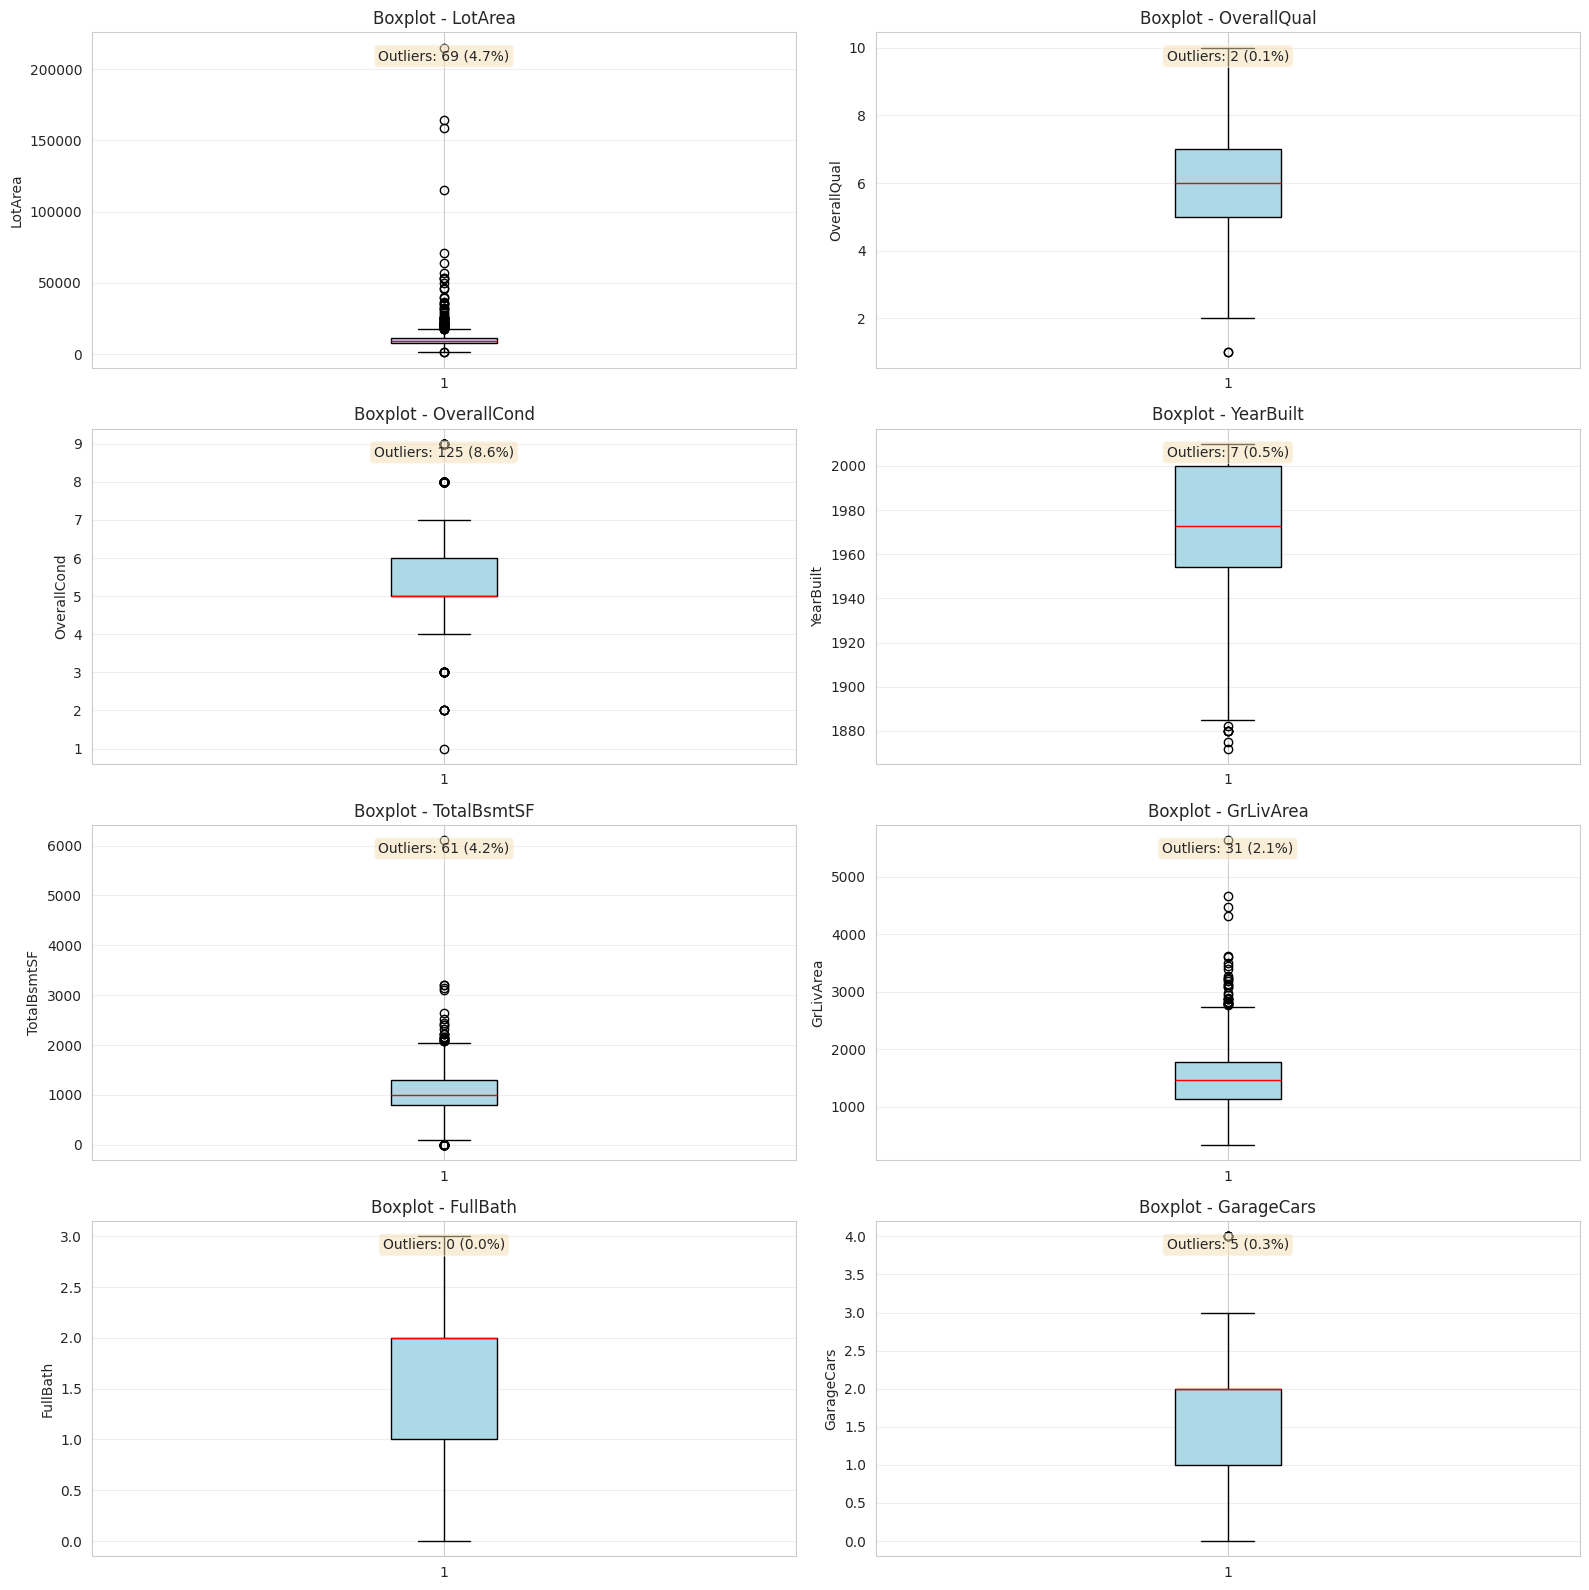

In [28]:
# ----------------------------------------------------------------
# 6. BOXPLOTS POUR LES VARIABLES NUMÉRIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("6. BOXPLOTS POUR DÉTECTER LES OUTLIERS")
print("-"*70)

# Boxplots pour les variables numériques importantes
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for i, col in enumerate(important_numeric):
    if col in df.columns and i < len(axes):
        bp = axes[i].boxplot(df[col], vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['medians'][0].set_color('red')
        axes[i].set_ylabel(col)
        axes[i].set_title(f'Boxplot - {col}')
        axes[i].grid(axis='y', alpha=0.3)

        # Ajouter statistiques
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        axes[i].text(0.5, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
                    transform=axes[i].transAxes, ha='center', va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


----------------------------------------------------------------------
7. DÉTECTION DES OUTLIERS
----------------------------------------------------------------------

RÉSUMÉ DES OUTLIERS PAR VARIABLE:
      Variable  Nb_Outliers Pct_Outliers  Borne_Inf  Borne_Sup
2  OverallCond          125        8.56%      3.500      7.500
0      LotArea           69        4.73%   1481.500  17673.500
4  TotalBsmtSF           61        4.18%     42.000   2052.000
5    GrLivArea           31        2.12%    158.625   2747.625
3    YearBuilt            7        0.48%   1885.000   2069.000
7   GarageCars            5        0.34%     -0.500      3.500
1  OverallQual            2        0.14%      2.000     10.000
6     FullBath            0        0.00%     -0.500      3.500

OUTLIERS POUR SALEPRICE:
  Borne inférieure: $3,937.50
  Borne supérieure: $340,037.50
  Nombre d'outliers: 61 (4.18%)


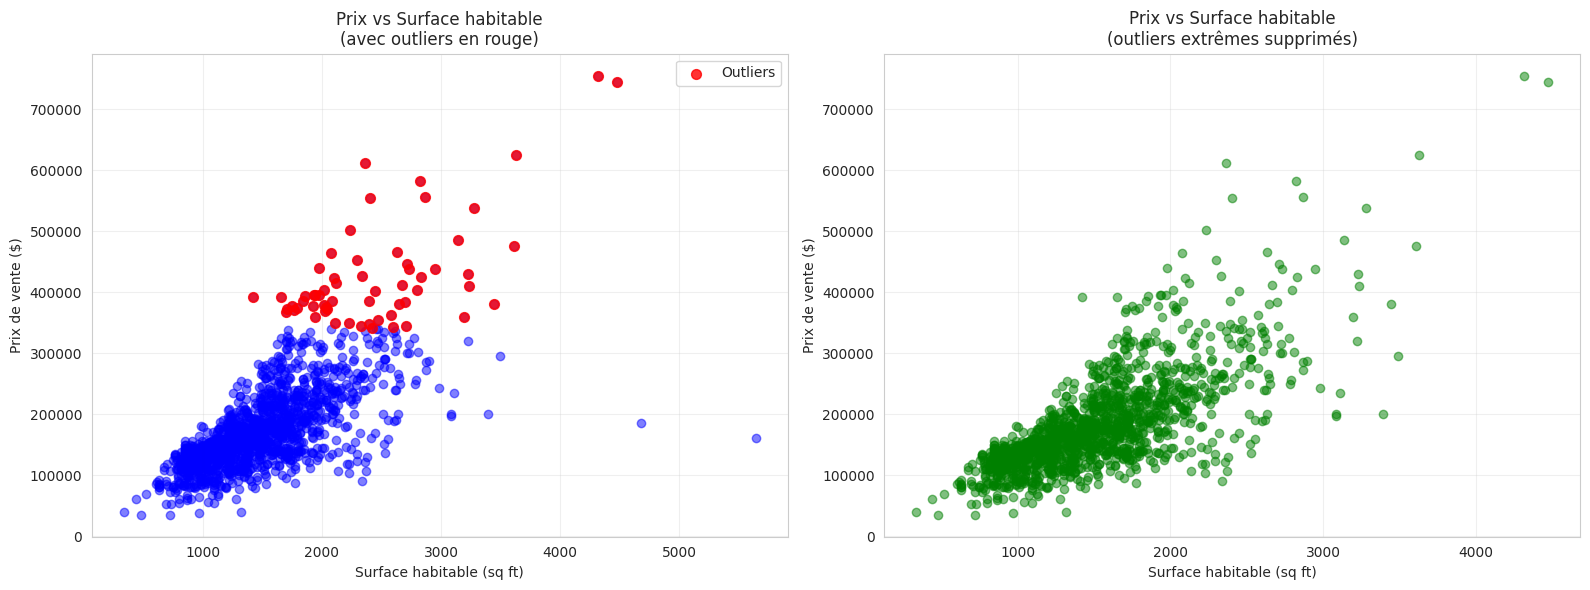


Nombre d'observations après nettoyage: 1458


In [29]:
# ----------------------------------------------------------------
# 7. FONCTION DE DÉTECTION DES OUTLIERS
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("7. DÉTECTION DES OUTLIERS")
print("-"*70)

def detect_outliers_iqr(data, column, threshold=1.5):
    """
    Détecte les outliers en utilisant la méthode IQR

    Paramètres:
    -----------
    data : DataFrame
        Le dataset
    column : str
        Nom de la colonne à analyser
    threshold : float
        Multiplicateur IQR (défaut: 1.5 pour outliers modérés, 3.0 pour extrêmes)

    Retourne:
    ---------
    outliers : DataFrame
        Lignes contenant des outliers
    lower_bound : float
        Limite inférieure
    upper_bound : float
        Limite supérieure
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

def detect_all_outliers(data, numeric_columns, threshold=1.5):
    """
    Détecte les outliers pour toutes les colonnes numériques
    """
    outliers_summary = []

    for col in numeric_columns:
        if col in data.columns:
            outliers, lower, upper = detect_outliers_iqr(data, col, threshold)
            outliers_summary.append({
                'Variable': col,
                'Nb_Outliers': len(outliers),
                'Pct_Outliers': f"{(len(outliers)/len(data)*100):.2f}%",
                'Borne_Inf': lower,
                'Borne_Sup': upper
            })

    return pd.DataFrame(outliers_summary).sort_values('Nb_Outliers', ascending=False)

# Détection des outliers
outliers_summary = detect_all_outliers(df, important_numeric)
print("\nRÉSUMÉ DES OUTLIERS PAR VARIABLE:")
print(outliers_summary)

# Analyse spécifique pour SalePrice
outliers_price, lower_price, upper_price = detect_outliers_iqr(df, 'SalePrice')
print(f"\nOUTLIERS POUR SALEPRICE:")
print(f"  Borne inférieure: ${lower_price:,.2f}")
print(f"  Borne supérieure: ${upper_price:,.2f}")
print(f"  Nombre d'outliers: {len(outliers_price)} ({len(outliers_price)/len(df)*100:.2f}%)")

# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avant suppression des outliers
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='blue')
axes[0].scatter(outliers_price['GrLivArea'], outliers_price['SalePrice'],
               color='red', s=50, alpha=0.8, label='Outliers')
axes[0].set_xlabel('Surface habitable (sq ft)')
axes[0].set_ylabel('Prix de vente ($)')
axes[0].set_title('Prix vs Surface habitable\n(avec outliers en rouge)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Après suppression des outliers extrêmes (pour visualisation)
# Supprimer les points avec GrLivArea > 4000 et prix < 300000
df_clean = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]
axes[1].scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.5, color='green')
axes[1].set_xlabel('Surface habitable (sq ft)')
axes[1].set_ylabel('Prix de vente ($)')
axes[1].set_title('Prix vs Surface habitable\n(outliers extrêmes supprimés)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNombre d'observations après nettoyage: {len(df_clean)}")

# Continuer avec le dataset nettoyé
df = df_clean.copy()


----------------------------------------------------------------------
8. TRANSFORMATION DE LA VARIABLE CIBLE
----------------------------------------------------------------------
Skewness SalePrice avant transformation: 1.8794
Skewness SalePrice après transformation: 0.1214


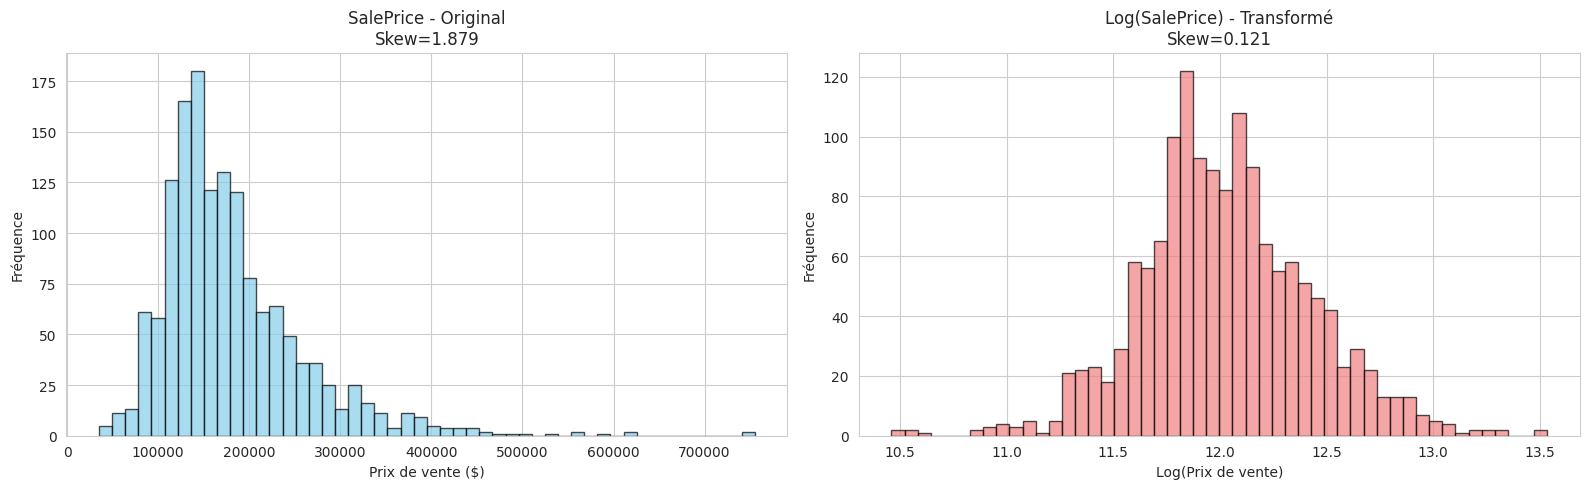

In [30]:
# ----------------------------------------------------------------
# 8. TRANSFORMATION DE LA VARIABLE CIBLE
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("8. TRANSFORMATION DE LA VARIABLE CIBLE")
print("-"*70)

# Appliquer la transformation logarithmique
df['SalePrice_Log'] = np.log(df['SalePrice'])

print(f"Skewness SalePrice avant transformation: {skew(df['SalePrice']):.4f}")
print(f"Skewness SalePrice après transformation: {skew(df['SalePrice_Log']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['SalePrice'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Prix de vente ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'SalePrice - Original\nSkew={skew(df["SalePrice"]):.3f}')

axes[1].hist(df['SalePrice_Log'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Log(Prix de vente)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Log(SalePrice) - Transformé\nSkew={skew(df["SalePrice_Log"]):.3f}')

plt.tight_layout()
plt.show()



----------------------------------------------------------------------
9. STANDARDISATION DES VARIABLES NUMÉRIQUES
----------------------------------------------------------------------
Nombre de variables numériques à standardiser: 36

Exemple de standardisation (première variable):
Variable: MSSubClass
  Moyenne avant: 56.89
  Écart-type avant: 42.33
  Moyenne après: -8.22e-17
  Écart-type après: 1.00


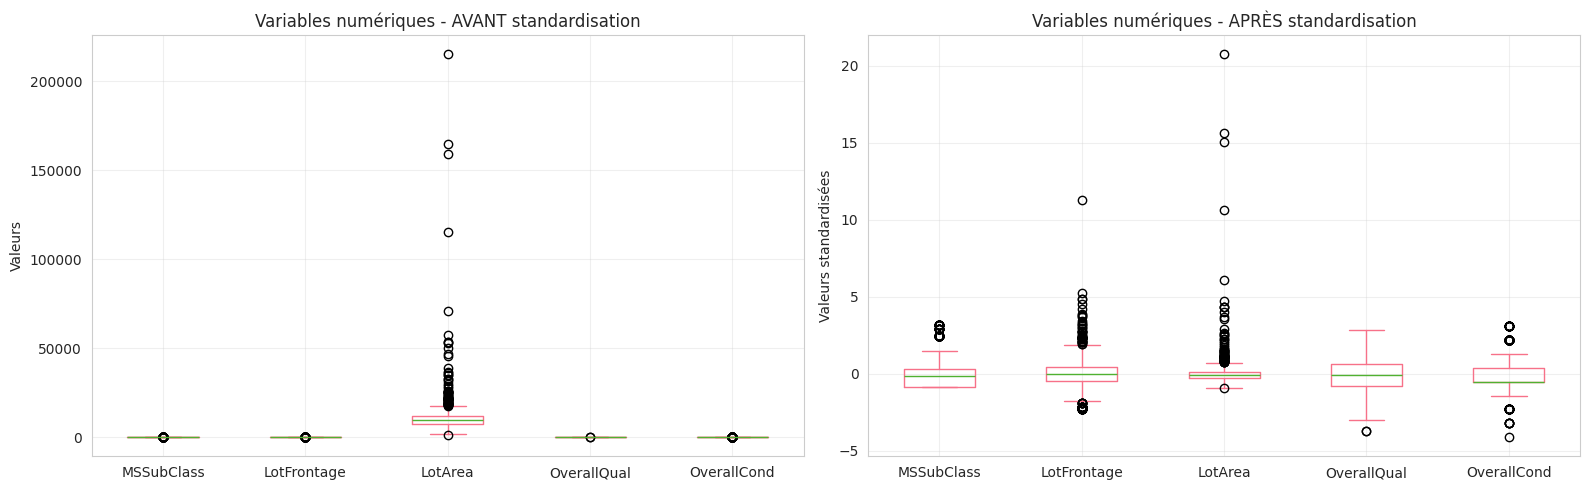

In [31]:
# ----------------------------------------------------------------
# 9. STANDARDISATION DES VARIABLES NUMÉRIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("9. STANDARDISATION DES VARIABLES NUMÉRIQUES")
print("-"*70)

# Mettre à jour la liste des variables numériques
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features
                   if col not in ['Id', 'SalePrice', 'SalePrice_Log']]

print(f"Nombre de variables numériques à standardiser: {len(numeric_features)}")

# Créer une copie pour la standardisation
df_scaled = df.copy()

# Standardisation
scaler = StandardScaler()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print("\nExemple de standardisation (première variable):")
print(f"Variable: {numeric_features[0]}")
print(f"  Moyenne avant: {df[numeric_features[0]].mean():.2f}")
print(f"  Écart-type avant: {df[numeric_features[0]].std():.2f}")
print(f"  Moyenne après: {df_scaled[numeric_features[0]].mean():.2e}")
print(f"  Écart-type après: {df_scaled[numeric_features[0]].std():.2f}")

# Visualisation de l'effet de la standardisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avant standardisation
sample_vars = numeric_features[:5]
df[sample_vars].plot(kind='box', ax=axes[0])
axes[0].set_title('Variables numériques - AVANT standardisation')
axes[0].set_ylabel('Valeurs')
axes[0].grid(True, alpha=0.3)

# Après standardisation
df_scaled[sample_vars].plot(kind='box', ax=axes[1])
axes[1].set_title('Variables numériques - APRÈS standardisation')
axes[1].set_ylabel('Valeurs standardisées')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# ----------------------------------------------------------------
# 10. ENCODING DES VARIABLES CATÉGORIQUES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("10. ENCODING DES VARIABLES CATÉGORIQUES")
print("-"*70)

# Variables catégoriques ordinales (avec ordre)
ordinal_mappings = {
    'ExterQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'HeatingQC': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
}

# Appliquer l'encoding ordinal
print("ENCODING ORDINAL:")
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df_scaled[col] = df[col].map(mapping)
        print(f"  • {col}: {len(mapping)} niveaux")

# Variables nominales - One-Hot Encoding
nominal_features = [col for col in categorical_features
                   if col not in ordinal_mappings.keys()]

print(f"\nONE-HOT ENCODING:")
print(f"  Nombre de variables nominales: {len(nominal_features)}")
print(f"  Exemples: {nominal_features[:5]}")

# Appliquer One-Hot Encoding
df_encoded = pd.get_dummies(df_scaled, columns=nominal_features, drop_first=True)

print(f"\nDimensions après encoding:")
print(f"  Avant: {df_scaled.shape}")
print(f"  Après: {df_encoded.shape}")
print(f"  Nouvelles colonnes créées: {df_encoded.shape[1] - df_scaled.shape[1]}")


----------------------------------------------------------------------
10. ENCODING DES VARIABLES CATÉGORIQUES
----------------------------------------------------------------------
ENCODING ORDINAL:
  • ExterQual: 5 niveaux
  • ExterCond: 5 niveaux
  • BsmtQual: 6 niveaux
  • BsmtCond: 6 niveaux
  • HeatingQC: 5 niveaux
  • KitchenQual: 5 niveaux
  • FireplaceQu: 6 niveaux
  • GarageQual: 6 niveaux
  • GarageCond: 6 niveaux
  • BsmtExposure: 5 niveaux
  • LotShape: 4 niveaux

ONE-HOT ENCODING:
  Nombre de variables nominales: 32
  Exemples: ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities']

Dimensions après encoding:
  Avant: (1458, 82)
  Après: (1458, 228)
  Nouvelles colonnes créées: 146


In [33]:
# ----------------------------------------------------------------
# 11. TRAIN-TEST SPLIT
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("11. SÉPARATION TRAIN-TEST")
print("-"*70)

# Préparer X et y
X = df_encoded.drop(['SalePrice', 'SalePrice_Log'], axis=1, errors='ignore')
y = df_encoded['SalePrice_Log']  # Utiliser la version log-transformée

print(f"Forme de X: {X.shape}")
print(f"Forme de y: {y.shape}")

# Split train-test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42)

print(f"\nRépartition Train-Test:")
print(f"  Train set: {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Nombre de features: {X_train.shape[1]}")




----------------------------------------------------------------------
11. SÉPARATION TRAIN-TEST
----------------------------------------------------------------------
Forme de X: (1458, 226)
Forme de y: (1458,)

Répartition Train-Test:
  Train set: 1166 observations (80.0%)
  Test set: 292 observations (20.0%)
  Nombre de features: 226


In [34]:
# ================================================================
# II. MODÉLISATION
# ================================================================

print("\n\n" + "="*70)
print("PARTIE II: MODÉLISATION")
print("="*70)

# Dictionnaire pour stocker les résultats
results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Entraîne et évalue un modèle
    """
    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Métriques sur l'ensemble d'entraînement
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Métriques sur l'ensemble de test
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Validation croisée
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()

    return {
        'Model': name,
        'Train_RMSE': train_rmse,
        'Train_MAE': train_mae,
        'Train_R2': train_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'Test_R2': test_r2,
        'CV_RMSE': cv_rmse,
        'Predictions_Train': y_train_pred,
        'Predictions_Test': y_test_pred
    }

print("\n" + "-"*70)
print("ENTRAÎNEMENT DES MODÈLES")
print("-"*70)



PARTIE II: MODÉLISATION

----------------------------------------------------------------------
ENTRAÎNEMENT DES MODÈLES
----------------------------------------------------------------------


In [35]:
# ----------------------------------------------------------------
# 1. LINEAR REGRESSION
# ----------------------------------------------------------------

print("\n1. LINEAR REGRESSION")
print("-" * 35)

lr_model = LinearRegression()
results['Linear Regression'] = evaluate_model('Linear Regression', lr_model,
                                              X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Linear Regression']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Linear Regression']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Linear Regression']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Linear Regression']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Linear Regression']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Linear Regression']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results['Linear Regression']['CV_RMSE']:.4f}")


1. LINEAR REGRESSION
-----------------------------------
  Train RMSE: 0.0896
  Test RMSE:  0.1369
  Train MAE:  0.0635
  Test MAE:   0.0931
  Train R²:   0.9490
  Test R²:    0.8888
  CV RMSE:    0.1313


In [36]:
# ----------------------------------------------------------------
# 2. LASSO REGRESSION
# ----------------------------------------------------------------

print("\n2. LASSO REGRESSION")
print("-" * 35)

lasso_model = Lasso(alpha=0.001, max_iter=10000, random_state=42)
results['Lasso'] = evaluate_model('Lasso', lasso_model,
                                 X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Lasso']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Lasso']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Lasso']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Lasso']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Lasso']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Lasso']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results['Lasso']['CV_RMSE']:.4f}")

# Nombre de coefficients non-nuls
non_zero_coef = np.sum(lasso_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef}/{len(lasso_model.coef_)}")


2. LASSO REGRESSION
-----------------------------------
  Train RMSE: 0.1043
  Test RMSE:  0.1223
  Train MAE:  0.0738
  Test MAE:   0.0850
  Train R²:   0.9309
  Test R²:    0.9113
  CV RMSE:    0.1162
  Coefficients non-nuls: 75/226


In [37]:
# ----------------------------------------------------------------
# 3. RIDGE REGRESSION
# ----------------------------------------------------------------

print("\n3. RIDGE REGRESSION")
print("-" * 35)

ridge_model = Ridge(alpha=10, random_state=42)
results['Ridge'] = evaluate_model('Ridge', ridge_model,
                                 X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Ridge']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Ridge']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Ridge']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Ridge']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Ridge']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Ridge']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results['Ridge']['CV_RMSE']:.4f}")


3. RIDGE REGRESSION
-----------------------------------
  Train RMSE: 0.0971
  Test RMSE:  0.1239
  Train MAE:  0.0688
  Test MAE:   0.0853
  Train R²:   0.9401
  Test R²:    0.9089
  CV RMSE:    0.1155


In [38]:
# ----------------------------------------------------------------
# 4. ELASTIC NET
# ----------------------------------------------------------------

print("\n4. ELASTIC NET")
print("-" * 35)

elasticnet_model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000,
                             random_state=42)
results['ElasticNet'] = evaluate_model('ElasticNet', elasticnet_model,
                                      X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['ElasticNet']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['ElasticNet']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['ElasticNet']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['ElasticNet']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['ElasticNet']['Train_R2']:.4f}")
print(f"  Test R²:    {results['ElasticNet']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results['ElasticNet']['CV_RMSE']:.4f}")

non_zero_coef_en = np.sum(elasticnet_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef_en}/{len(elasticnet_model.coef_)}")


4. ELASTIC NET
-----------------------------------
  Train RMSE: 0.1008
  Test RMSE:  0.1229
  Train MAE:  0.0714
  Test MAE:   0.0852
  Train R²:   0.9355
  Test R²:    0.9104
  CV RMSE:    0.1156
  Coefficients non-nuls: 97/226



----------------------------------------------------------------------
COMPARAISON DES MODÈLES
----------------------------------------------------------------------

TABLEAU COMPARATIF:
           Modèle  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2  CV_RMSE
Linear Regression    0.089638   0.136900   0.063540  0.093076  0.948961 0.888826 0.131339
            Lasso    0.104309   0.122267   0.073781  0.084980  0.930887 0.911322 0.116227
            Ridge    0.097129   0.123945   0.068788  0.085263  0.940074 0.908871 0.115520
       ElasticNet    0.100760   0.122871   0.071421  0.085172  0.935510 0.910444 0.115612


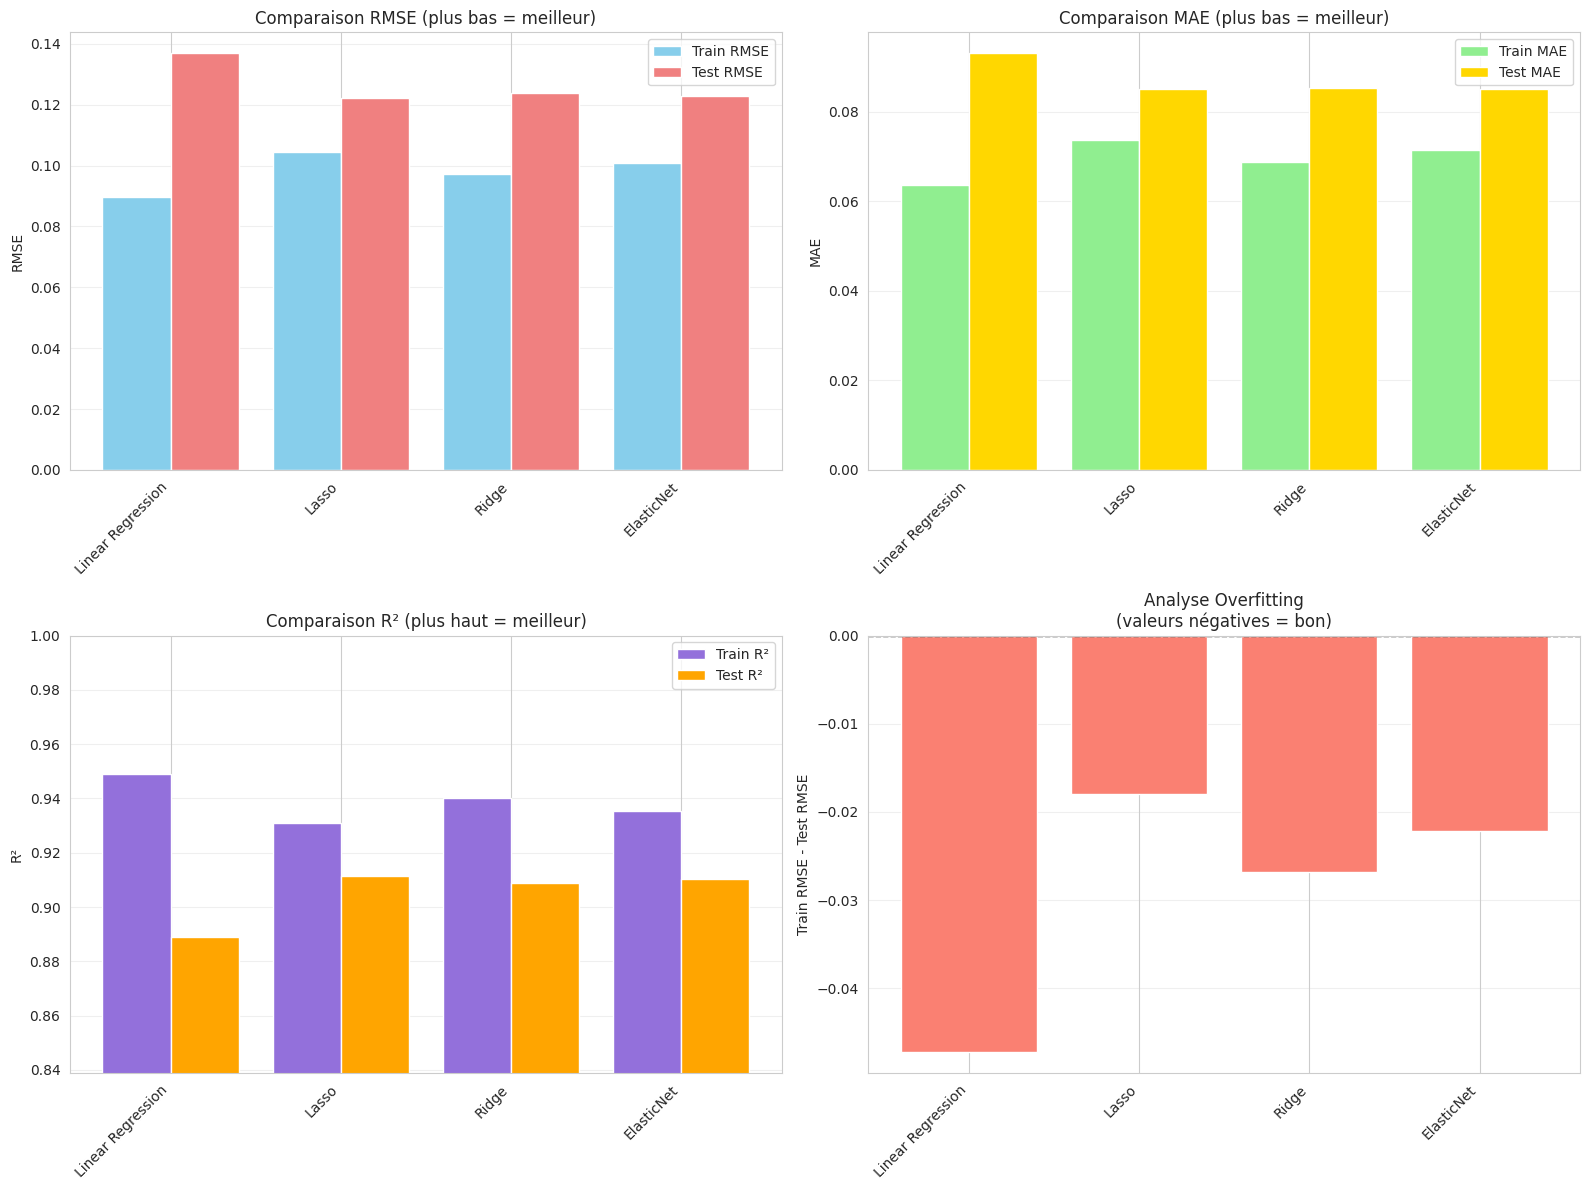

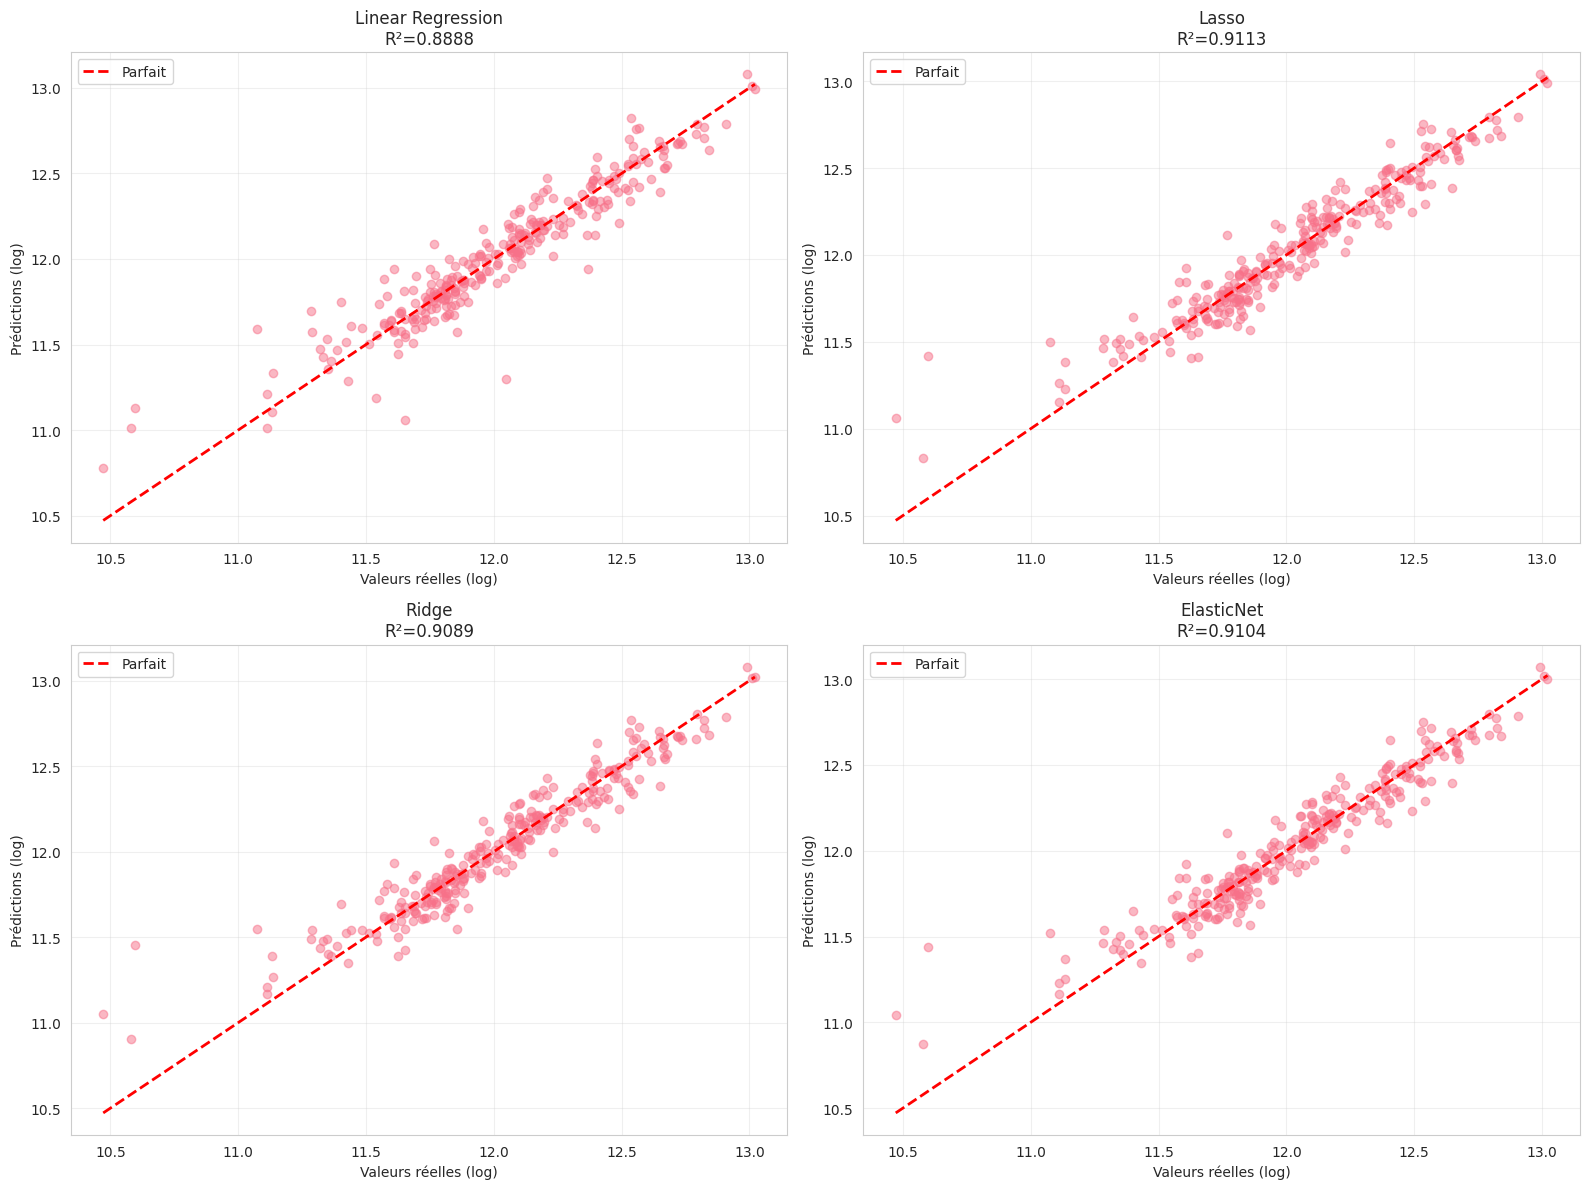

In [39]:
# ----------------------------------------------------------------
# COMPARAISON DES MODÈLES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("COMPARAISON DES MODÈLES")
print("-"*70)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Train_RMSE': [results[m]['Train_RMSE'] for m in results.keys()],
    'Test_RMSE': [results[m]['Test_RMSE'] for m in results.keys()],
    'Train_MAE': [results[m]['Train_MAE'] for m in results.keys()],
    'Test_MAE': [results[m]['Test_MAE'] for m in results.keys()],
    'Train_R2': [results[m]['Train_R2'] for m in results.keys()],
    'Test_R2': [results[m]['Test_R2'] for m in results.keys()],
    'CV_RMSE': [results[m]['CV_RMSE'] for m in results.keys()]
})

print("\nTABLEAU COMPARATIF:")
print(comparison_df.to_string(index=False))

# Visualisation de la comparaison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = list(results.keys())
x_pos = np.arange(len(models))

# RMSE Comparison
axes[0, 0].bar(x_pos - 0.2, comparison_df['Train_RMSE'], 0.4,
              label='Train RMSE', color='skyblue')
axes[0, 0].bar(x_pos + 0.2, comparison_df['Test_RMSE'], 0.4,
              label='Test RMSE', color='lightcoral')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('Comparaison RMSE (plus bas = meilleur)')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[0, 1].bar(x_pos - 0.2, comparison_df['Train_MAE'], 0.4,
              label='Train MAE', color='lightgreen')
axes[0, 1].bar(x_pos + 0.2, comparison_df['Test_MAE'], 0.4,
              label='Test MAE', color='gold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Comparaison MAE (plus bas = meilleur)')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1, 0].bar(x_pos - 0.2, comparison_df['Train_R2'], 0.4,
              label='Train R²', color='mediumpurple')
axes[1, 0].bar(x_pos + 0.2, comparison_df['Test_R2'], 0.4,
              label='Test R²', color='orange')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_title('Comparaison R² (plus haut = meilleur)')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([min(comparison_df['Test_R2'])-0.05, 1.0])

# Overfitting analysis (différence Train-Test)
overfit_rmse = comparison_df['Train_RMSE'] - comparison_df['Test_RMSE']
axes[1, 1].bar(x_pos, overfit_rmse, color='salmon')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
axes[1, 1].set_ylabel('Train RMSE - Test RMSE')
axes[1, 1].set_title('Analyse Overfitting\n(valeurs négatives = bon)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Prédictions vs Valeurs réelles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models):
    y_pred = results[model_name]['Predictions_Test']

    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Parfait')
    axes[i].set_xlabel('Valeurs réelles (log)')
    axes[i].set_ylabel('Prédictions (log)')
    axes[i].set_title(f'{model_name}\nR²={results[model_name]["Test_R2"]:.4f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
X_train.dtypes.value_counts()


,count
bool,178
float64,36
int64,12


In [41]:
X_train.select_dtypes(include='object').head()


""
254
1066
865
799
380


In [42]:
# Conversion explicite des booléens en entiers (0 ou 1)
X_train = X_train.astype({col: 'int' for col in X_train.select_dtypes('bool').columns})
X_test = X_test.astype({col: 'int' for col in X_test.select_dtypes('bool').columns})


selected_features, removed_features = backward_elimination(X_train, y_train, significance_level=0.05)


NameError: name 'backward_elimination' is not defined

In [ ]:
# ================================================================
# III. SÉLECTION DE VARIABLES - BACKWARD ELIMINATION
# ================================================================

print("\n\n" + "="*70)
print("PARTIE III: SÉLECTION DE VARIABLES PAR BACKWARD ELIMINATION")
print("="*70)

print("\n" + "-"*70)
print("BACKWARD ELIMINATION")
print("-"*70)

def backward_elimination(X, y, significance_level=0.05):
    """
    Effectue une élimination backward basée sur les p-values

    Paramètres:
    -----------
    X : DataFrame
        Features
    y : Series
        Target
    significance_level : float
        Seuil de significativité (défaut: 0.05)

    Retourne:
    ---------
    selected_features : list
        Liste des features sélectionnées
    """
    features = list(X.columns)
    removed_features = []

    print(f"\nDébut: {len(features)} variables")
    print(f"Seuil de significativité: {significance_level}")

    iteration = 0
    while True:
        iteration += 1

        # Ajouter une constante
        X_with_const = sm.add_constant(X[features])

        # Ajuster le modèle
        model = sm.OLS(y, X_with_const).fit()

        # Trouver la variable avec la p-value la plus élevée
        p_values = model.pvalues.iloc[1:]  # Exclure la constante
        max_p_value = p_values.max()

        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            removed_features.append((excluded_feature, max_p_value))

            if iteration <= 10 or iteration % 10 == 0:
                print(f"Itération {iteration}: Retrait de '{excluded_feature}' (p-value={max_p_value:.4f})")
        else:
            break

    print(f"\nTerminé après {iteration} itérations")
    print(f"Variables conservées: {len(features)}")
    print(f"Variables retirées: {len(removed_features)}")

    return features, removed_features

# Appliquer backward elimination
selected_features, removed_features = backward_elimination(X_train, y_train,
                                                          significance_level=0.05)

print(f"\n{len(selected_features)} variables sélectionnées sur {X_train.shape[1]}")
print(f"Réduction: {(1 - len(selected_features)/X_train.shape[1])*100:.1f}%")

# Afficher quelques variables retirées
print("\nPremières variables retirées (Top 10 p-values):")
removed_sorted = sorted(removed_features, key=lambda x: x[1], reverse=True)
for feat, pval in removed_sorted[:10]:
    print(f"  • {feat}: p-value = {pval:.6f}")

# Préparer les nouveaux ensembles train/test avec les variables sélectionnées
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nNouvelles dimensions:")
print(f"  X_train: {X_train_selected.shape}")
print(f"  X_test: {X_test_selected.shape}")


In [ ]:
# ----------------------------------------------------------------
# MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES
# ----------------------------------------------------------------

print("\n" + "-"*70)
print("MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES")
print("-"*70)

# Dictionnaire pour stocker les résultats avec sélection
results_selected = {}

In [ ]:
# ----------------------------------------------------------------
# 1. LINEAR REGRESSION (avec sélection)
# ----------------------------------------------------------------

print("\n1. LINEAR REGRESSION (Variables sélectionnées)")
print("-" * 48)

lr_model_selected = LinearRegression()
results_selected['Linear Regression'] = evaluate_model(
    'Linear Regression', lr_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Linear Regression']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Linear Regression']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Linear Regression']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Linear Regression']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Linear Regression']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Linear Regression']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Linear Regression']['CV_RMSE']:.4f}")

In [ ]:
# ----------------------------------------------------------------
# 2. LASSO REGRESSION (avec sélection)
# ----------------------------------------------------------------

print("\n2. LASSO REGRESSION (Variables sélectionnées)")
print("-" * 48)

lasso_model_selected = Lasso(alpha=0.001, max_iter=10000, random_state=42)
results_selected['Lasso'] = evaluate_model(
    'Lasso', lasso_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Lasso']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Lasso']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Lasso']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Lasso']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Lasso']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Lasso']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Lasso']['CV_RMSE']:.4f}")

In [ ]:
# ----------------------------------------------------------------
# 3. RIDGE REGRESSION (avec sélection)
# ----------------------------------------------------------------

print("\n3. RIDGE REGRESSION (Variables sélectionnées)")
print("-" * 48)

ridge_model_selected = Ridge(alpha=10, random_state=42)
results_selected['Ridge'] = evaluate_model(
    'Ridge', ridge_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Ridge']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Ridge']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Ridge']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Ridge']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Ridge']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Ridge']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Ridge']['CV_RMSE']:.4f}")


In [ ]:
# ----------------------------------------------------------------
# 4. ELASTIC NET (avec sélection)
# ----------------------------------------------------------------

print("\n4. ELASTIC NET (Variables sélectionnées)")
print("-" * 48)

elasticnet_model_selected = ElasticNet(alpha=0.001, l1_ratio=0.5,
                                      max_iter=10000, random_state=42)
results_selected['ElasticNet'] = evaluate_model(
    'ElasticNet', elasticnet_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['ElasticNet']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['ElasticNet']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['ElasticNet']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['ElasticNet']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['ElasticNet']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['ElasticNet']['Test_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['ElasticNet']['CV_RMSE']:.4f}")


In [ ]:
# ----------------------------------------------------------------
# COMPARAISON FINALE: AVEC ET SANS SÉLECTION
# ----------------------------------------------------------------

print("\n" + "="*70)
print("COMPARAISON FINALE: TOUTES VARIABLES VS VARIABLES SÉLECTIONNÉES")
print("="*70)

# Créer un DataFrame de comparaison
comparison_final = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Toutes_Var_Test_RMSE': [results[m]['Test_RMSE'] for m in results.keys()],
    'Toutes_Var_Test_R2': [results[m]['Test_R2'] for m in results.keys()],
    'Select_Var_Test_RMSE': [results_selected[m]['Test_RMSE'] for m in results_selected.keys()],
    'Select_Var_Test_R2': [results_selected[m]['Test_R2'] for m in results_selected.keys()],
})

# Calculer les améliorations
comparison_final['Amélioration_RMSE'] = comparison_final['Toutes_Var_Test_RMSE'] - comparison_final['Select_Var_Test_RMSE']
comparison_final['Amélioration_R2'] = comparison_final['Select_Var_Test_R2'] - comparison_final['Toutes_Var_Test_R2']

print("\nTABLEAU COMPARATIF FINAL:")
print(comparison_final.to_string(index=False))

# Visualisation de la comparaison finale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = list(results.keys())
x_pos = np.arange(len(models))

# RMSE Comparison
axes[0].bar(x_pos - 0.2, comparison_final['Toutes_Var_Test_RMSE'], 0.4,
           label='Toutes variables', color='skyblue')
axes[0].bar(x_pos + 0.2, comparison_final['Select_Var_Test_RMSE'], 0.4,
           label='Variables sélectionnées', color='lightcoral')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Comparaison Test RMSE\n(plus bas = meilleur)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1].bar(x_pos - 0.2, comparison_final['Toutes_Var_Test_R2'], 0.4,
           label='Toutes variables', color='mediumpurple')
axes[1].bar(x_pos + 0.2, comparison_final['Select_Var_Test_R2'], 0.4,
           label='Variables sélectionnées', color='orange')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Comparaison Test R²\n(plus haut = meilleur)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------
# RÉSUMÉ ET RECOMMANDATIONS
# ----------------------------------------------------------------

print("\n" + "="*70)
print("RÉSUMÉ ET RECOMMANDATIONS")
print("="*70)

# Trouver le meilleur modèle
best_model_all = comparison_final.loc[comparison_final['Toutes_Var_Test_R2'].idxmax(), 'Modèle']
best_r2_all = comparison_final['Toutes_Var_Test_R2'].max()
best_rmse_all = comparison_final.loc[comparison_final['Toutes_Var_Test_R2'].idxmax(), 'Toutes_Var_Test_RMSE']

best_model_selected = comparison_final.loc[comparison_final['Select_Var_Test_R2'].idxmax(), 'Modèle']
best_r2_selected = comparison_final['Select_Var_Test_R2'].max()
best_rmse_selected = comparison_final.loc[comparison_final['Select_Var_Test_R2'].idxmax(), 'Select_Var_Test_RMSE']

print(f"\n🏆 MEILLEUR MODÈLE (Toutes variables):")
print(f"   Modèle: {best_model_all}")
print(f"   Test R²: {best_r2_all:.4f}")
print(f"   Test RMSE: {best_rmse_all:.4f}")
print(f"   Nombre de variables: {X_train.shape[1]}")

print(f"\n🏆 MEILLEUR MODÈLE (Variables sélectionnées):")
print(f"   Modèle: {best_model_selected}")
print(f"   Test R²: {best_r2_selected:.4f}")
print(f"   Test RMSE: {best_rmse_selected:.4f}")
print(f"   Nombre de variables: {len(selected_features)}")

print(f"\n📊 STATISTIQUES GÉNÉRALES:")
print(f"   Variables initiales: {X_train.shape[1]}")
print(f"   Variables après sélection: {len(selected_features)}")
print(f"   Réduction: {(1 - len(selected_features)/X_train.shape[1])*100:.1f}%")

print(f"\n💡 RECOMMANDATIONS:")
if best_r2_selected > best_r2_all:
    print(f"   ✓ La sélection de variables AMÉLIORE les performances")
    print(f"   ✓ Gain en R²: {(best_r2_selected - best_r2_all):.4f}")
    print(f"   ✓ Réduction en RMSE: {(best_rmse_all - best_rmse_selected):.4f}")
    print(f"   → Recommandation: Utiliser {best_model_selected} avec {len(selected_features)} variables")
else:
    print(f"   ✓ Toutes les variables donnent de meilleures performances")
    print(f"   → Recommandation: Utiliser {best_model_all} avec toutes les variables")

print(f"\n🎯 PROCHAINES ÉTAPES:")
print(f"   1. Optimiser les hyperparamètres (GridSearchCV)")
print(f"   2. Essayer des modèles plus complexes (Random Forest, Gradient Boosting)")
print(f"   3. Créer des features supplémentaires (feature engineering)")
print(f"   4. Analyser les résidus pour identifier les patterns")
print(f"   5. Traiter les outliers de manière plus sophistiquée")

print("\n" + "="*70)
print("FIN DU NOTEBOOK")
print("="*70)